# PPO from scratch — **V1: Learned value baseline (a critic)**

Second of six. V0 was vanilla policy gradient. V1 adds **one** thing: a *learned, state-dependent
baseline* `V(s)` subtracted from the reward-to-go.

| Version | Concept |
|---|---|
| V0 | Vanilla PG (REINFORCE + reward-to-go) |
| **V1 (this)** | **Learned value baseline — a critic network** |
| V2 | Fixed-horizon rollout buffer + bootstrapping |
| V3 | GAE-λ advantage |
| V4 | PPO-clip surrogate + multiple update passes |
| V5 | KL early-stop + advantage normalization |

### The idea
In V0 each action was weighted by its raw reward-to-go `R_t`. Unbiased, but high variance:
the weight answers *"was this whole trajectory good?"* rather than *"was this action better than
expected from this state?"*. You already saw that a naive **global-mean** baseline is worse than
none — it collapsed exploration, because one scalar can't tell a near-goal state from a hopeless
one. The fix is a baseline that depends on the **state**:

$$A(s_t, a_t) \;=\; R_t \;-\; V(s_t)$$

`V(s)` is a second network estimating the expected return *from state `s`*. Subtracting it doesn't
bias the gradient — `V(s)` doesn't depend on the action, so it can't change which action is
favored (same zero-mean-score argument as before) — but it slashes variance: the weight becomes
"did this action beat the value I predicted for this state?", centered near zero and signed.

### What you add in V1
1. A **critic** network `V(s)`: obs → a single scalar.
2. A **value loss**: regress `V(s)` toward the reward-to-go (your Monte-Carlo return targets).
3. In the policy update, use **advantage** `R_t − V(s_t)` as the weight instead of raw `R_t`.

Two networks, two optimizers, two losses. Your `compute_loss` is unchanged — only the `weights`
you feed it change from returns to advantages.

> **Subtlety to get right (think about it, no code given):** from the policy's perspective the
> advantage is a *fixed number*. Make sure the `V(s)` you subtract is **detached** from the
> critic's graph, so the policy update doesn't leak gradients into the critic (and the critic's
> regression target doesn't pull on the policy). Two separate `backward()` calls, two separate
> optimizers, cleanly isolated.

### ✅ Done-when
- The **critic self-test** cell (given) passes — your `MyCritic` + `compute_value_loss` can
  overfit a toy regression.
- During training the printed **`v_loss` decreases** — the critic is actually fitting returns.
- The **advantage diagnostic** shows mean ≈ 0 with both signs.
- Eval should be **dramatically better and tighter than V0** — the reference V1 lands around
  **−80 to −130 greedy with the ± roughly 3–6× smaller** than V0's. The V0 greedy-vs-stochastic
  gap should also largely close: a lower-variance gradient builds a genuinely confident policy
  instead of one leaning on its own randomness.

> Kernel: `ppo`. Everything from V0 is reused as-is except the two TODO cells.


## Imports & configuration *(given — V1 adds critic knobs)*

In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.distributions.categorical import Categorical
import torch.nn.functional as F
import gymnasium as gym
from gymnasium.spaces import Discrete, Box

# ---- experiment configuration ----------------------------------------------
ENV_NAME   = "Acrobot-v1"
SEED       = 0
HIDDEN     = [64, 64]
LR         = 1e-2          # policy (actor) learning rate
EPOCHS     = 15
BATCH_SIZE = 4000
GAMMA      = 0.99

# ---- NEW in V1: critic knobs -----------------------------------------------
VALUE_LR        = 1e-2     # critic learning rate
VALUE_FIT_ITERS = 80       # gradient steps to fit the critic per epoch. Unlike the
                           # policy (updated once, to stay on-policy), the value fit is
                           # just supervised regression on this batch -- you may iterate it.

print("gymnasium", gym.__version__, "| torch", torch.__version__)

gymnasium 1.3.0 | torch 2.13.0+cpu


## Policy + env helpers *(given — your V0 code, unchanged)*

In [2]:
class MyPolicy(nn.Module):
    def __init__(self, input_size: int, output_size: int) -> None:
        super().__init__()
        sizes = [input_size] + HIDDEN + [output_size]
        layers = []
        for in_sz, out_sz in zip(sizes, sizes[1:]):
            layers.append(nn.Linear(in_sz, out_sz))
            layers.append(nn.Tanh())
        layers = layers[:-1]
        self.linear_layers = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> Categorical:
        return Categorical(logits=self.linear_layers(x))

    def greedy(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear_layers(x).argmax()

    def sample(self, x: torch.Tensor) -> torch.Tensor:
        return self(x).sample()


def make_env(env_name: str = ENV_NAME, render_mode: str | None = None) -> gym.Env:
    return gym.make(env_name, render_mode=render_mode)


def set_seed(env: gym.Env, seed: int = SEED) -> None:
    torch.manual_seed(seed)
    np.random.seed(seed)
    env.reset(seed=seed)
    env.action_space.seed(seed)


_e = make_env()
OBS_DIM = _e.observation_space.shape[0]
N_ACTS  = _e.action_space.n
MAX_STEPS = _e.spec.max_episode_steps
print(f"{ENV_NAME}: obs_dim={OBS_DIM}, n_acts={N_ACTS}, max_steps={MAX_STEPS}")
_e.close()

Acrobot-v1: obs_dim=6, n_acts=3, max_steps=500


## reward-to-go + policy loss *(given — your V0 code, unchanged)*

In [3]:
def reward_to_go(rews: list[float], gamma: float = GAMMA) -> list[float]:
    """Discounted reward-to-go for one episode."""
    n = len(rews)
    gamma_pows = gamma ** np.arange(n)
    cum_rews = []
    for i in range(n):
        left = n - i
        cr = (rews[i:] * gamma_pows[:left]).sum()
        cum_rews.append(cr)
    return cum_rews


def compute_loss(policy: MyPolicy, obs: torch.Tensor, act: torch.Tensor,
                 weights: torch.Tensor) -> torch.Tensor:
    """Policy-gradient loss. In V1 `weights` are ADVANTAGES, not raw reward-to-go."""
    logp = policy(obs).log_prob(act)
    return -((logp) * weights).mean()

## 1. The critic network *(you implement)*

Build `MyCritic`: a network that maps an observation to a **single scalar** `V(s)` — the
estimated return from that state. It's the same shape of thing as `MyPolicy`, but the head is
width 1 and there's no `Categorical`. Think about the trailing dimension: for a batch of `N`
observations you want `V` to come out as shape `(N,)`, not `(N, 1)`, so it lines up with your
per-step returns.

In [4]:
class MyCritic(nn.Module):
    def __init__(self, input_size: int) -> None:
        super().__init__()
        sizes = [input_size] + HIDDEN 
        layers = []
        for in_sz, out_sz in zip(sizes, sizes[1:]):
            layers.append(nn.Linear(in_sz, out_sz))
            layers.append(nn.Tanh())
        layers.append(nn.Linear(HIDDEN[-1], 1))
        self.linear_layers = nn.Sequential(*layers)
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear_layers(x).squeeze(-1)

## 2. The value loss *(you implement)*

The critic is trained by **regression**: push `V(s)` toward the reward-to-go targets you already
compute (those Monte-Carlo returns are unbiased estimates of the true value). Implement
`compute_value_loss(critic, obs, returns)` — a standard regression loss between `V(obs)` and
`returns`.

In [5]:
def compute_value_loss(critic: MyCritic, obs: torch.Tensor, returns: torch.Tensor) -> torch.Tensor:
    y = critic(obs)
    return F.mse_loss(y, returns)

### 🔬 Self-test — critic can fit a toy regression *(given)*

In [6]:
def _test_critic() -> None:
    """Sanity: a fresh MyCritic + your value loss should overfit a trivial target."""
    torch.manual_seed(0)
    c = MyCritic(OBS_DIM, 1) if _critic_takes_out_dim() else MyCritic(OBS_DIM)
    opt = Adam(c.parameters(), lr=1e-2)
    obs = torch.randn(64, OBS_DIM)
    target = 3.0 * obs[:, 0] - 1.0          # arbitrary function of the obs
    first = None
    for _ in range(300):
        opt.zero_grad(); loss = compute_value_loss(c, obs, target); loss.backward(); opt.step()
        if first is None: first = loss.item()
    v = c(obs)
    assert v.shape == target.shape, f"V(obs) shape {tuple(v.shape)} must equal {tuple(target.shape)}"
    assert loss.item() < 0.25 * first, f"value loss barely moved: {first:.3f} -> {loss.item():.3f}"
    print(f"critic self-test OK: loss {first:.3f} -> {loss.item():.4f}, V shape {tuple(v.shape)}")

def _critic_takes_out_dim() -> bool:
    import inspect
    try:
        return len(inspect.signature(MyCritic.__init__).parameters) >= 3
    except (ValueError, TypeError):
        return False

_test_critic()

critic self-test OK: loss 9.105 -> 0.0013, V shape (64,)


## 3. Collect a batch & take both steps *(you implement)*

Same collection loop as V0 (roll out `NUM_TRAJECTORIES` episodes, accumulate obs / actions /
per-episode reward-to-go). What's new is the **update**, now two parts:

1. Compute `values = V(obs)` and form `advantages = returns − values` (mind the detach — see the
   subtlety note at the top).
2. **Policy step:** feed *advantages* (not raw returns) as the weights to `compute_loss`, then
   `backward()` + `optimizer.step()`.
3. **Value step:** fit the critic to `returns` with `compute_value_loss`, for `VALUE_FIT_ITERS`
   gradient steps, using `value_optimizer`.

Return `(batch_rets, batch_lens, value_loss)` — same first two as V0, plus the final scalar value
loss so the driver can show the critic learning.

In [7]:
NUM_TRAJECTORIES = 32

def train_one_epoch(env: gym.Env) -> tuple[list[float], list[int], torch.Tensor]:
    # TODO (V1): collect NUM_TRAJECTORIES episodes as in V0 (obs, actions, per-episode
    #   reward-to-go). Then, instead of weighting by raw returns:
    #     - ask the critic for its value estimate of every stored observation
    #     - turn returns into advantages by subtracting those values (detached)
    #     - update the policy once, feeding advantages as the weights to compute_loss
    #     - separately, fit the critic to the returns for VALUE_FIT_ITERS steps
    #   Return (batch_rets, batch_lens, final_value_loss).
    obs_batch =[]
    action_batch =[]
    rewards_batch =[]
    total_reward_per_ep=[]
    episodes_lens=[]
    for _ in range(NUM_TRAJECTORIES):
        rewards = []
        obs = torch.tensor(env.reset()[0], dtype = torch.float32)
        finished = False
        while not finished:
            with torch.no_grad():
                action = policy_net.sample(obs)
            next_obs, rew, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            obs_batch.append(obs)
            action_batch.append(action)
            rewards.append(rew)
            if done:
                timeout = len(rewards) == MAX_STEPS
                episodes_lens.append(len(rewards))
                break
            else:
                obs = torch.tensor(next_obs, dtype=torch.float32)
        acc_rewards = reward_to_go(rewards)
        rewards_batch += acc_rewards
        total_reward_per_ep.append(sum(rewards))
    obs_batch_tensor = torch.stack(obs_batch)
    actions_tensor = torch.tensor(action_batch)
    rewards_tensor = torch.tensor(rewards_batch)
    with torch.no_grad():
        values = critic_net(obs_batch_tensor)
    for _ in range(VALUE_FIT_ITERS):
        critic_optimizer.zero_grad()
        critic_loss = compute_value_loss(critic_net, obs_batch_tensor, rewards_tensor)
        critic_loss.backward()
        critic_optimizer.step()
    
  
    optimizer.zero_grad()
    loss = compute_loss(policy_net, obs_batch_tensor, actions_tensor, rewards_tensor - values )
    loss.backward()
    optimizer.step()
        
    return total_reward_per_ep, episodes_lens, critic_loss

## Evaluation & recording harness *(given — your V0 code)*

In [8]:
def greedy_action(obs: np.ndarray) -> torch.Tensor:
    with torch.no_grad():
        return policy_net.greedy(torch.tensor(obs, dtype=torch.float32))


def evaluate(env_name: str = ENV_NAME, n_episodes: int = 10, seed: int = 1000) -> tuple[float, float]:
    """Average greedy return over n_episodes. Our comparison metric."""
    env = make_env(env_name)
    rets = []
    for i in range(n_episodes):
        obs, _ = env.reset(seed=seed + i)
        done, ep_ret = False, 0.0
        while not done:
            obs, r, terminated, truncated, _ = env.step(greedy_action(obs))
            done = terminated or truncated
            ep_ret += r
        rets.append(ep_ret)
    env.close()
    return float(np.mean(rets)), float(np.std(rets))


def record_gif(out_path: str, env_name: str = ENV_NAME, episodes: int = 3, fps: int = 15) -> None:
    """Greedy rollout -> GIF saved to disk AND shown inline (animated) in the notebook."""
    try:
        import imageio
        env = make_env(env_name, render_mode="rgb_array")
        frames = []
        for _ in range(episodes):
            obs, done = env.reset()[0], False
            while not done:
                frames.append(env.render())
                obs, _, terminated, truncated, _ = env.step(greedy_action(obs))
                done = terminated or truncated
        env.close()
        imageio.mimsave(out_path, frames, fps=fps)
        print(f"saved {len(frames)} frames -> {out_path}")
        # embed the animated GIF in the cell output (persists when the notebook reopens)
        from IPython.display import Image, display
        display(Image(filename=out_path))
    except Exception as ex:
        print("record_gif skipped (likely headless):", repr(ex))

## Train *(given — drives your code)*

Instantiate the critic + its optimizer next to the policy. If your `MyCritic.__init__` takes only
`obs_dim`, drop the second argument.

In [9]:
env = make_env()
set_seed(env, SEED)

policy_net = MyPolicy(OBS_DIM, N_ACTS)
optimizer  = Adam(policy_net.parameters(), lr=LR)

critic_net = MyCritic(OBS_DIM)
critic_optimizer = Adam(critic_net.parameters(), lr = VALUE_LR)


for epoch in range(EPOCHS):
    batch_rets, batch_lens, v_loss = train_one_epoch(env)
    print("epoch %3d \t return %8.1f \t ep_len %6.1f \t v_loss %8.2f" %
          (epoch, np.mean(batch_rets), np.mean(batch_lens), v_loss))
env.close()

/tmp/ipykernel_10424/1131805173.py:13: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /__w/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:822.)
  print("epoch %3d \t return %8.1f \t ep_len %6.1f \t v_loss %8.2f" %


epoch   0 	 return   -500.0 	 ep_len  500.0 	 v_loss  1562.26


epoch   1 	 return   -325.5 	 ep_len  326.5 	 v_loss   391.34


epoch   2 	 return   -240.3 	 ep_len  241.3 	 v_loss   196.21


epoch   3 	 return   -185.9 	 ep_len  186.9 	 v_loss   158.32


...

epoch  10 	 return    -93.2 	 ep_len   94.2 	 v_loss   116.66


epoch  11 	 return    -93.7 	 ep_len   94.7 	 v_loss   180.15


epoch  12 	 return    -95.4 	 ep_len   96.4 	 v_loss   133.30


epoch  13 	 return   -101.3 	 ep_len  102.3 	 v_loss   264.92


epoch  14 	 return    -92.5 	 ep_len   93.5 	 v_loss   162.80


## ✅ Verify V1 *(given)*

advantage: mean +3.36  std 10.13  frac>0 0.71  min -44.6  max 27.5



V1 greedy return on Acrobot-v1: -88.6 +/- 28.5
Compare to your V0 baseline -- watch the +/- spread, not just the mean.


saved 235 frames -> v1_baseline.gif


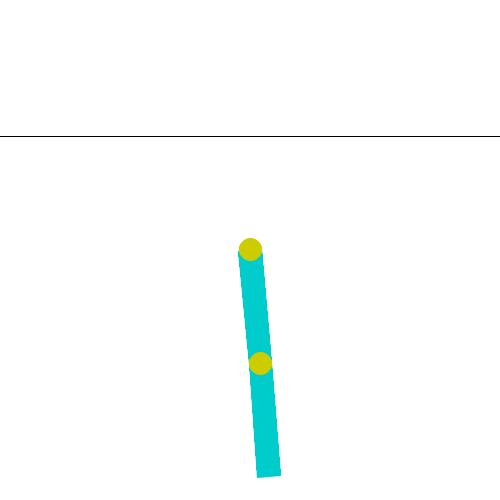

In [10]:
# advantage diagnostic: collect one fresh batch and inspect A = returns - V(s)
def advantage_stats(n_traj: int = 32) -> None:
    env = make_env(); obs_all, ret_all = [], []
    for _ in range(n_traj):
        o, _ = env.reset(); r = []
        done = False
        while not done:
            with torch.no_grad(): a = policy_net.sample(torch.tensor(o, dtype=torch.float32))
            o2, rew, term, trunc, _ = env.step(a); obs_all.append(o); r.append(rew); o = o2
            done = term or trunc
        ret_all += reward_to_go(r)
    env.close()
    obs_t = torch.tensor(np.array(obs_all), dtype=torch.float32)
    ret_t = torch.tensor(np.array(ret_all), dtype=torch.float32)
    with torch.no_grad(): adv = ret_t - critic_net(obs_t)
    a = adv.numpy()
    print(f"advantage: mean {a.mean():+.2f}  std {a.std():.2f}  frac>0 {(a>0).mean():.2f}  "
          f"min {a.min():.1f}  max {a.max():.1f}")

advantage_stats()

mean_ret, std_ret = evaluate(n_episodes=30)
print(f"\nV1 greedy return on {ENV_NAME}: {mean_ret:.1f} +/- {std_ret:.1f}")
print("Compare to your V0 baseline -- watch the +/- spread, not just the mean.")
record_gif("v1_baseline.gif")

---
### When V1 is done
Ping me with your eval line and I'll review the critic wiring (especially the detach) before
generating **V2**, which stops collecting whole episodes and instead fills a **fixed-size buffer**,
learning to *bootstrap* `V(s)` when an episode is cut off by the epoch boundary rather than a
true terminal — the piece that makes long-horizon control work.